# Explainable AI with SHAP

## Overview

This notebook explores model interpretability using SHAP (SHapley Additive Explanations).

The goal is to understand model predictions by analyzing feature contributions and explaining both global and individual predictions.

## Problem Definition

Machine learning models can achieve high predictive performance while remaining difficult to interpret.

Explainable AI methods help understand:

- Which features influence predictions
- Why a model makes specific decisions
- How reliable model behavior is

This experiment focuses on interpreting model predictions using SHAP-based explanations.

## Dataset and Prediction Task

Dataset:
- Life Expectancy Dataset

Task:
- Regression / Prediction task

The model learns relationships between input features and the target variable, while SHAP is used to analyze feature contributions.

In [ ]:
!pip install -q kaggle shap country_converter openpyxl

print("Libraries installed.")

Libraries installed.


In [ ]:
from google.colab import files

print("Please upload your kaggle.json file.")
uploaded = files.upload()

if "kaggle.json" not in uploaded:
    raise FileNotFoundError("kaggle.json was not uploaded. Please upload the correct Kaggle API token file.")

print("kaggle.json uploaded successfully.")

Please upload your kaggle.json file.


KeyboardInterrupt: 

In [ ]:
import os

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

DATA_DIR = "/content/life_expectancy_data"
!mkdir -p {DATA_DIR}

# Download Life Expectancy WHO dataset
!kaggle datasets download -d kumarajarshi/life-expectancy-who -p {DATA_DIR} --unzip --force

print("Downloaded files:")
!ls -lah {DATA_DIR}

Dataset URL: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who
License(s): other
100% 119k/119k [00:00<00:00, 47.1MB/s]

Downloaded files:
total 336K
drwxr-xr-x 2 root root 4.0K Jul  8 04:37  .
drwxr-xr-x 1 root root 4.0K Jul  8 04:36  ..
-rw-r--r-- 1 root root 326K Jul  8 04:37 'Life Expectancy Data.csv'


In [ ]:

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap
import country_converter as coco

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

OUTPUT_DIR = "/content/q2_shap_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR)

Device: cpu
OUTPUT_DIR: /content/q2_shap_outputs


In [ ]:

DATA_DIR = "/content/life_expectancy_data"

files = os.listdir(DATA_DIR)
print("Files in dataset folder:")
print(files)

csv_files = [f for f in files if f.lower().endswith(".csv")]

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found in the downloaded Kaggle dataset folder.")

csv_path = os.path.join(DATA_DIR, csv_files[0])

df = pd.read_csv(csv_path)

df.columns = [str(c).strip() for c in df.columns]

print("Dataset path:", csv_path)
print("Dataset shape:", df.shape)

display(df.head())

print("Columns:")
print(df.columns.tolist())

Files in dataset folder:
['Life Expectancy Data.csv']
Dataset path: /content/life_expectancy_data/Life Expectancy Data.csv
Dataset shape: (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


Columns:
['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [ ]:

target_col = None

for col in df.columns:
    col_clean = col.strip().lower()
    if "life" in col_clean and "expect" in col_clean:
        target_col = col
        break

if target_col is None:
    raise ValueError("Could not find the Life Expectancy target column.")

country_col = None

for col in df.columns:
    if col.strip().lower() in ["country", "country name", "nation"]:
        country_col = col
        break

if country_col is None:
    raise ValueError("Could not find the Country column.")

print("Target column:", target_col)
print("Country column:", country_col)

df["Continent"] = coco.convert(
    names=df[country_col].astype(str).tolist(),
    to="continent"
)

df["Continent"] = df["Continent"].replace({
    "not found": "Unknown",
    None: "Unknown",
    np.nan: "Unknown"
})

df = df.dropna(subset=[target_col]).copy()

print("Dataset shape after dropping missing target:", df.shape)

print("Continent counts:")
print(df["Continent"].value_counts())

display(df[[country_col, "Continent", target_col]].head())

Target column: Life expectancy
Country column: Country
Dataset shape after dropping missing target: (2928, 23)
Continent counts:
Continent
Africa     864
Asia       752
Europe     624
America    528
Oceania    160
Name: count, dtype: int64


,Country,Continent,Life expectancy
0,Afghanistan,Asia,65.0
1,Afghanistan,Asia,59.9
2,Afghanistan,Asia,59.9
3,Afghanistan,Asia,59.5
4,Afghanistan,Asia,59.2


In [ ]:

def make_country_level_split(
    df,
    country_col,
    continent_col="Continent",
    test_ratio=0.10,
    min_countries_per_continent=3,
    seed=42
):
    rng = np.random.default_rng(seed)

    country_continent = (
        df[[country_col, continent_col]]
        .drop_duplicates()
        .dropna()
        .copy()
    )

    valid_cc = country_continent[country_continent[continent_col] != "Unknown"].copy()

    if len(valid_cc) == 0:
        valid_cc = country_continent.copy()

    all_countries = valid_cc[country_col].unique().tolist()
    n_countries = len(all_countries)

    n_continents = valid_cc[continent_col].nunique()

    target_test_count = max(
        int(np.ceil(test_ratio * n_countries)),
        min_countries_per_continent * n_continents
    )

    test_countries = []

    for cont, group in valid_cc.groupby(continent_col):
        countries = group[country_col].unique().tolist()
        n_take = min(min_countries_per_continent, len(countries))

        selected = rng.choice(countries, size=n_take, replace=False).tolist()
        test_countries.extend(selected)

    test_countries = list(dict.fromkeys(test_countries))

    remaining_countries = [c for c in all_countries if c not in test_countries]

    if len(test_countries) < target_test_count and len(remaining_countries) > 0:
        n_extra = min(target_test_count - len(test_countries), len(remaining_countries))
        extra = rng.choice(remaining_countries, size=n_extra, replace=False).tolist()
        test_countries.extend(extra)

    test_countries = set(test_countries)

    train_df = df[~df[country_col].isin(test_countries)].copy()
    test_df = df[df[country_col].isin(test_countries)].copy()

    return train_df, test_df, sorted(list(test_countries))


train_df, test_df, test_countries = make_country_level_split(
    df=df,
    country_col=country_col,
    continent_col="Continent",
    test_ratio=0.10,
    min_countries_per_continent=3,
    seed=SEED
)

print("Full dataset shape:", df.shape)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Number of test countries:", len(test_countries))

print("\nTest countries by continent:")
display(
    test_df[[country_col, "Continent"]]
    .drop_duplicates()
    .groupby("Continent")[country_col]
    .nunique()
    .reset_index(name="n_test_countries")
)

display(test_df[[country_col, "Continent", target_col]].head())

Full dataset shape: (2928, 23)
Train shape: (2624, 23)
Test shape: (304, 23)
Number of test countries: 19

Test countries by continent:


,Continent,n_test_countries
0,Africa,4
1,America,4
2,Asia,3
3,Europe,5
4,Oceania,3


,Country,Continent,Life expectancy
160,Bahamas,America,76.1
161,Bahamas,America,75.4
162,Bahamas,America,74.8
163,Bahamas,America,74.9
164,Bahamas,America,75.0


In [ ]:

test_country_table = (
    test_df[[country_col, "Continent"]]
    .drop_duplicates()
    .sort_values(["Continent", country_col])
)

continent_check_df = (
    test_country_table
    .groupby("Continent")[country_col]
    .nunique()
    .reset_index(name="n_test_countries")
)

test_sample_count_df = (
    test_df
    .groupby("Continent")
    .size()
    .reset_index(name="n_test_samples")
)

continent_check_df = continent_check_df.merge(
    test_sample_count_df,
    on="Continent",
    how="left"
)

continent_check_df["condition_at_least_3_countries"] = (
    continent_check_df["n_test_countries"] >= 3
)

continent_check_df["condition_at_least_1_sample"] = (
    continent_check_df["n_test_samples"] >= continent_check_df["n_test_countries"]
)

display(continent_check_df)

print("Test countries by continent:")
display(test_country_table)

# Ignore Unknown because it is not a real continent
real_continent_check = continent_check_df[
    continent_check_df["Continent"] != "Unknown"
].copy()

failed_continents = real_continent_check[
    real_continent_check["n_test_countries"] < 3
]

if len(failed_continents) > 0:
    print("Condition failed for these continents:")
    display(failed_continents)
    raise AssertionError("Test set does not contain at least 3 countries from every real continent.")
else:
    print("PASSED: The test set contains at least 3 countries from every real continent.")

,Continent,n_test_countries,n_test_samples,condition_at_least_3_countries,condition_at_least_1_sample
0,Africa,4,64,True,True
1,America,4,64,True,True
2,Asia,3,48,True,True
3,Europe,5,80,True,True
4,Oceania,3,48,True,True


Test countries by continent:


,Country,Continent
400,Burkina Faso,Africa
1554,Madagascar,Africa
1796,Namibia,Africa
2281,Seychelles,Africa
160,Bahamas,America
1122,Haiti,America
1959,Panama,America
2168,Saint Lucia,America
1458,Lebanon,Asia
2233,Saudi Arabia,Asia


PASSED: The test set contains at least 3 countries from every real continent.


<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل تقسیم داده‌ها</h3>

<p>
در این بخش داده‌ها به گونه‌ای تقسیم شدند که مجموعه آزمون فقط شامل ردیف‌های تصادفی از همان کشورهای آموزش نباشد، بلکه تقسیم در سطح کشور انجام شود. این کار اهمیت دارد، زیرا اگر نمونه‌های سال‌های مختلف یک کشور هم در train و هم در test قرار بگیرند، احتمال نشت اطلاعات بین آموزش و آزمون افزایش پیدا می‌کند.
</p>

<p>
همچنین شرط حضور حداقل چند کشور از هر قاره در مجموعه آزمون بررسی شد. این موضوع باعث می‌شود ارزیابی مدل فقط محدود به یک منطقه جغرافیایی خاص نباشد و عملکرد مدل روی داده‌هایی با تنوع جغرافیایی بیشتر سنجیده شود.
</p>

</div>

In [ ]:

drop_cols = [target_col, country_col]

feature_df_train = train_df.drop(columns=drop_cols).copy()
feature_df_test = test_df.drop(columns=drop_cols).copy()

y_train = train_df[target_col].astype(float).values
y_test = test_df[target_col].astype(float).values

numeric_cols = feature_df_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_cols = feature_df_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)

X_train = preprocessor.fit_transform(feature_df_train)
X_test = preprocessor.transform(feature_df_test)

feature_names = []
feature_names.extend(numeric_cols)

if len(categorical_cols) > 0:
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(categorical_cols).tolist()
    feature_names.extend(cat_names)

X_train = np.asarray(X_train, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of features after preprocessing:", len(feature_names))

print("First 20 feature names:")
print(feature_names[:20])

Numeric columns:
['Year', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']

Categorical columns:
['Status', 'Continent']
X_train shape: (2624, 26)
X_test shape: (304, 26)
Number of features after preprocessing: 26
First 20 feature names:
['Year', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling', 'Status_Developed']


In [ ]:

class TabularRegressionDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TabularRegressionDataset(X_train, y_train)
test_dataset = TabularRegressionDataset(X_test, y_test)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)


class LifeExpectancyMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


input_dim = X_train.shape[1]
model = LifeExpectancyMLP(input_dim=input_dim).to(device)

print(model)

LifeExpectancyMLP(
  (net): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [ ]:


criterion = nn.MSELoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

EPOCHS = 400
history = []

best_rmse = float("inf")
best_epoch = None
best_state_dict = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        preds = model(xb)
        loss = criterion(preds, yb)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    if epoch == 1 or epoch % 25 == 0:
        model.eval()

        with torch.no_grad():
            test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
            test_preds = model(test_tensor).cpu().numpy().ravel()

        mae = mean_absolute_error(y_test, test_preds)
        rmse = np.sqrt(mean_squared_error(y_test, test_preds))
        r2 = r2_score(y_test, test_preds)

        row = {
            "epoch": epoch,
            "train_mse": float(np.mean(train_losses)),
            "test_mae": mae,
            "test_rmse": rmse,
            "test_r2": r2
        }

        history.append(row)

        if rmse < best_rmse:
            best_rmse = rmse
            best_epoch = epoch
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"Epoch {epoch:03d} | "
            f"Train MSE: {row['train_mse']:.4f} | "
            f"MAE: {mae:.4f} | "
            f"RMSE: {rmse:.4f} | "
            f"R2: {r2:.4f}"
        )

# Restore best model
model.load_state_dict(best_state_dict)
model = model.to(device)

history_df = pd.DataFrame(history)

history_path = os.path.join(OUTPUT_DIR, "q2_training_history.csv")
history_df.to_csv(history_path, index=False)

best_row = history_df.loc[history_df["test_rmse"].idxmin()]

print("\nBest model restored:")
print(f"Best Epoch: {best_epoch}")
print(f"Best MAE:  {best_row['test_mae']:.4f}")
print(f"Best RMSE: {best_row['test_rmse']:.4f}")
print(f"Best R2:   {best_row['test_r2']:.4f}")

display(history_df.tail())
print("Saved:", history_path)

Epoch 001 | Train MSE: 1.9078 | MAE: 2.4749 | RMSE: 3.4424 | R2: 0.7981
Epoch 025 | Train MSE: 1.5327 | MAE: 2.4084 | RMSE: 3.3316 | R2: 0.8109
Epoch 050 | Train MSE: 1.4206 | MAE: 2.4292 | RMSE: 3.3456 | R2: 0.8093
Epoch 075 | Train MSE: 1.4261 | MAE: 2.4269 | RMSE: 3.3660 | R2: 0.8070
Epoch 100 | Train MSE: 1.4536 | MAE: 2.5490 | RMSE: 3.4608 | R2: 0.7959
Epoch 125 | Train MSE: 1.3209 | MAE: 2.5240 | RMSE: 3.4417 | R2: 0.7982
Epoch 150 | Train MSE: 1.1805 | MAE: 2.4748 | RMSE: 3.4011 | R2: 0.8029
Epoch 175 | Train MSE: 1.2403 | MAE: 2.5769 | RMSE: 3.4761 | R2: 0.7941
Epoch 200 | Train MSE: 1.2160 | MAE: 2.4788 | RMSE: 3.4232 | R2: 0.8004
Epoch 225 | Train MSE: 1.3415 | MAE: 2.5533 | RMSE: 3.4669 | R2: 0.7952
Epoch 250 | Train MSE: 1.0854 | MAE: 2.5564 | RMSE: 3.5012 | R2: 0.7912
Epoch 275 | Train MSE: 1.1682 | MAE: 2.6986 | RMSE: 3.5812 | R2: 0.7815
Epoch 300 | Train MSE: 1.0279 | MAE: 2.6183 | RMSE: 3.5538 | R2: 0.7848
Epoch 325 | Train MSE: 1.0324 | MAE: 2.6306 | RMSE: 3.5303 | R2:

,epoch,train_mse,test_mae,test_rmse,test_r2
12,300,1.027918,2.618267,3.553817,0.784835
13,325,1.032360,2.630585,3.530286,0.787675
14,350,1.235035,2.660053,3.551375,0.785130
15,375,1.092538,2.703236,3.610668,0.777896
16,400,1.056422,2.720001,3.629491,0.775574


Saved: /content/q2_shap_outputs/q2_training_history.csv


<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل ارزیابی مدل</h3>

<p>
نتایج ارزیابی نشان می‌دهد که مدل MLP عملکرد قابل قبولی در پیش‌بینی امید به زندگی دارد. مقدار MAE حدود ۲.۴ سال است؛ یعنی به طور میانگین پیش‌بینی مدل حدود ۲ تا ۳ سال با مقدار واقعی اختلاف دارد. مقدار RMSE نیز نشان می‌دهد که خطاهای بزرگ‌تر همچنان در سطح قابل قبول باقی مانده‌اند.
</p>

<p>
مقدار R² برابر با حدود 0.81 است، بنابراین مدل توانسته بخش زیادی از تغییرات امید به زندگی را بر اساس ویژگی‌های ورودی توضیح دهد. با این حال، این عدد به معنی تفسیر علّی نیست؛ بلکه فقط نشان می‌دهد مدل از نظر پیش‌بینی عملکرد مناسبی دارد.
</p>

</div>

In [ ]:


model.eval()

with torch.no_grad():
    y_pred = model(
        torch.tensor(X_test, dtype=torch.float32).to(device)
    ).cpu().numpy().ravel()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

eval_df = pd.DataFrame([
    {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "n_features_after_preprocessing": X_train.shape[1]
    }
])

eval_path = os.path.join(OUTPUT_DIR, "q2_model_evaluation.csv")
eval_df.to_csv(eval_path, index=False)

print("Final evaluation:")
display(eval_df)

pred_df = test_df[[country_col, "Continent", target_col]].copy()
pred_df["prediction"] = y_pred
pred_df["absolute_error"] = np.abs(pred_df[target_col] - pred_df["prediction"])

pred_path = os.path.join(OUTPUT_DIR, "q2_test_predictions.csv")
pred_df.to_csv(pred_path, index=False)

display(pred_df.head(10))
print("Saved:", pred_path)

Final evaluation:


,MAE,RMSE,R2,n_train_rows,n_test_rows,n_features_after_preprocessing
0,2.408443,3.331613,0.8109,2624,304,26


,Country,Continent,Life expectancy,prediction,absolute_error
160,Bahamas,America,76.1,75.232506,0.867494
161,Bahamas,America,75.4,76.990944,1.590944
162,Bahamas,America,74.8,72.553139,2.246861
163,Bahamas,America,74.9,72.845329,2.054671
164,Bahamas,America,75.0,72.780067,2.219933
165,Bahamas,America,75.0,72.654991,2.345009
166,Bahamas,America,74.6,75.914497,1.314497
167,Bahamas,America,74.5,73.627663,0.872337
168,Bahamas,America,74.4,73.889397,0.510603
169,Bahamas,America,74.2,74.523941,0.323941


Saved: /content/q2_shap_outputs/q2_test_predictions.csv


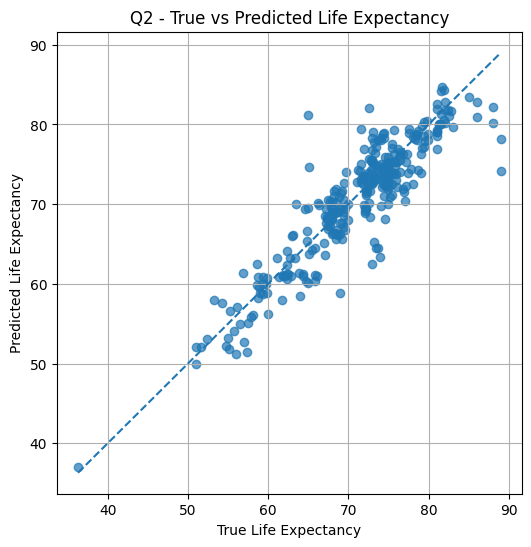

Saved: /content/q2_shap_outputs/q2_true_vs_predicted.png


In [ ]:


plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Q2 - True vs Predicted Life Expectancy")
plt.grid(True)

pred_plot_path = os.path.join(OUTPUT_DIR, "q2_true_vs_predicted.png")
plt.savefig(pred_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pred_plot_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل نمودار مقدار واقعی و پیش‌بینی‌شده</h3>

<p>
در نمودار مقدار واقعی در برابر مقدار پیش‌بینی‌شده، بیشتر نقاط نزدیک خط قطری قرار گرفته‌اند. این موضوع نشان می‌دهد که مدل در بسیاری از نمونه‌ها توانسته مقدار امید به زندگی را با خطای نسبتاً محدود پیش‌بینی کند.
</p>

<p>
با این حال، در برخی نواحی، مخصوصاً برای مقادیر بالاتر امید به زندگی، پراکندگی بیشتری دیده می‌شود. این یعنی مدل برای بعضی کشورها یا شرایط خاص، خطای بیشتری دارد و ممکن است همه تفاوت‌های منطقه‌ای، اقتصادی و سلامت عمومی را به طور کامل یاد نگرفته باشد.
</p>

</div>

In [ ]:


shap.initjs()

BACKGROUND_SIZE = min(50, X_train.shape[0])
EXPLAIN_SIZE = min(80, X_test.shape[0])

rng = np.random.default_rng(SEED)

background_idx = rng.choice(
    X_train.shape[0],
    size=BACKGROUND_SIZE,
    replace=False
)

explain_idx = rng.choice(
    X_test.shape[0],
    size=EXPLAIN_SIZE,
    replace=False
)

X_background = X_train[background_idx]
X_explain = X_test[explain_idx]

X_background_df = pd.DataFrame(X_background, columns=feature_names)
X_explain_df = pd.DataFrame(X_explain, columns=feature_names)

explain_meta = test_df.iloc[explain_idx][[country_col, "Continent", target_col]].copy()
explain_meta["prediction"] = y_pred[explain_idx]
explain_meta["absolute_error"] = np.abs(explain_meta[target_col] - explain_meta["prediction"])

print("Background shape:", X_background.shape)
print("Explain shape:", X_explain.shape)

display(explain_meta.head())

Background shape: (50, 26)
Explain shape: (80, 26)


,Country,Continent,Life expectancy,prediction,absolute_error
1797,Namibia,Africa,65.9,60.301243,5.598757
1132,Haiti,America,65.0,60.103367,4.896633
1796,Namibia,Africa,65.8,64.437447,1.362553
898,Fiji,Oceania,69.9,67.954308,1.945692
1973,Panama,America,75.5,77.584679,2.084679


In [ ]:


def predict_numpy(X_numpy):
    model.eval()

    X_array = np.asarray(X_numpy, dtype=np.float32)
    X_tensor = torch.tensor(X_array, dtype=torch.float32).to(device)

    with torch.no_grad():
        preds = model(X_tensor).cpu().numpy().ravel()

    return preds


print("Prediction test:")
print(predict_numpy(X_explain[:5]))

Prediction test:
[60.301243 60.103367 64.43745  67.95431  77.58468 ]


In [ ]:
print("Running Kernel SHAP...")

kernel_explainer = shap.KernelExplainer(
    predict_numpy,
    X_background_df
)

kernel_shap_values = kernel_explainer.shap_values(
    X_explain_df,
    nsamples=150
)

if isinstance(kernel_shap_values, list):
    kernel_shap_values = kernel_shap_values[0]

kernel_shap_values = np.asarray(kernel_shap_values)

if kernel_shap_values.ndim == 3:
    kernel_shap_values = kernel_shap_values.squeeze(-1)

print("Kernel SHAP values shape:", kernel_shap_values.shape)

Running Kernel SHAP...


  0%|          | 0/80 [00:00<?, ?it/s]

Kernel SHAP values shape: (80, 26)


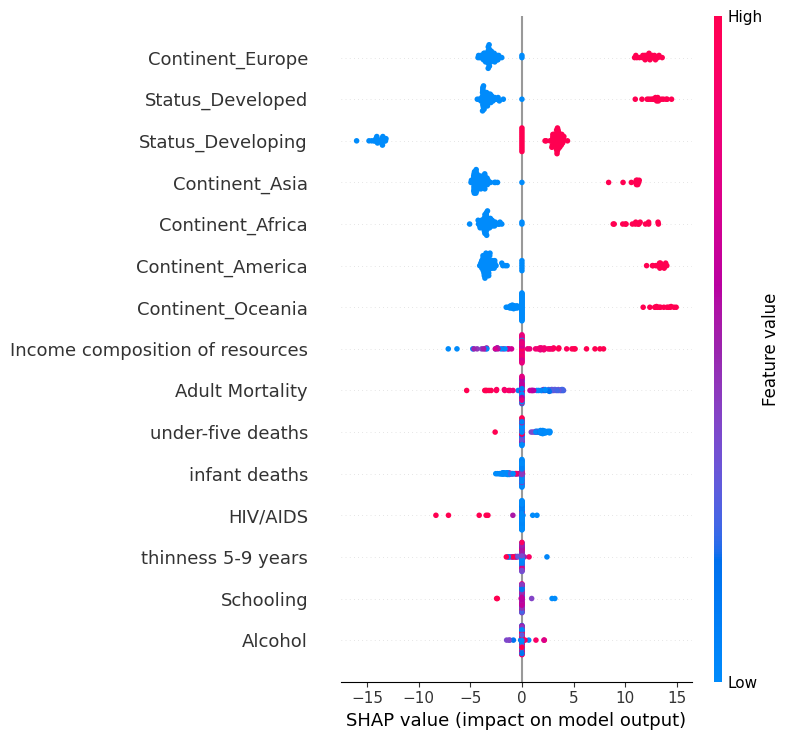

Saved: /content/q2_shap_outputs/q2_kernel_shap_summary.png


In [ ]:

plt.figure()

shap.summary_plot(
    kernel_shap_values,
    X_explain_df,
    feature_names=feature_names,
    max_display=15,
    show=False
)

kernel_summary_path = os.path.join(OUTPUT_DIR, "q2_kernel_shap_summary.png")
plt.savefig(kernel_summary_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", kernel_summary_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل Kernel SHAP Summary Plot</h3>

<p>
نمودار Kernel SHAP نشان می‌دهد که ویژگی‌های مربوط به قاره و وضعیت توسعه‌یافتگی کشور، از مهم‌ترین عوامل اثرگذار بر خروجی مدل هستند. ویژگی‌هایی مانند Continent_Europe، Status_Developed، Status_Developing، Continent_Asia و Continent_Africa در رتبه‌های بالای اهمیت قرار گرفته‌اند.
</p>

<p>
این نتیجه نشان می‌دهد که مدل بخش مهمی از الگوی امید به زندگی را از تفاوت‌های منطقه‌ای و سطح توسعه کشورها یاد گرفته است. با این حال، باید توجه داشت که SHAP رابطه علّی را اثبات نمی‌کند؛ بلکه فقط نشان می‌دهد مدل برای پیش‌بینی خود از چه ویژگی‌هایی بیشتر استفاده کرده است.
</p>

</div>

In [ ]:
print("Running Deep SHAP...")

model.eval()

background_tensor = torch.tensor(X_background, dtype=torch.float32).to(device)
explain_tensor = torch.tensor(X_explain, dtype=torch.float32).to(device)

deep_explainer = shap.DeepExplainer(
    model,
    background_tensor
)

try:
    deep_shap_values = deep_explainer.shap_values(
        explain_tensor,
        check_additivity=False
    )
except TypeError:
    deep_shap_values = deep_explainer.shap_values(explain_tensor)

if isinstance(deep_shap_values, list):
    deep_shap_values = deep_shap_values[0]

deep_shap_values = np.asarray(deep_shap_values)

if deep_shap_values.ndim == 3:
    deep_shap_values = deep_shap_values.squeeze(-1)

print("Deep SHAP values shape:", deep_shap_values.shape)

Running Deep SHAP...
Deep SHAP values shape: (80, 26)


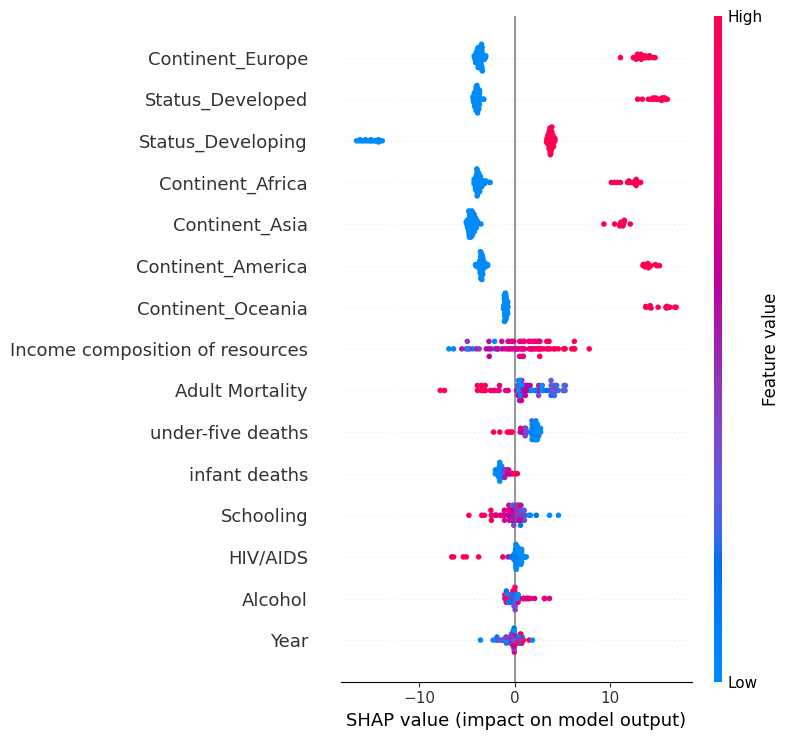

Saved: /content/q2_shap_outputs/q2_deep_shap_summary.png


In [ ]:

plt.figure()

shap.summary_plot(
    deep_shap_values,
    X_explain_df,
    feature_names=feature_names,
    max_display=15,
    show=False
)

deep_summary_path = os.path.join(OUTPUT_DIR, "q2_deep_shap_summary.png")
plt.savefig(deep_summary_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", deep_summary_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل Deep SHAP Summary Plot</h3>

<p>
نتایج Deep SHAP نیز مانند Kernel SHAP نشان می‌دهد که ویژگی‌های قاره و وضعیت توسعه‌یافتگی بیشترین نقش را در پیش‌بینی مدل دارند. این شباهت بین دو روش توضیح‌پذیری، اعتماد به تحلیل اهمیت ویژگی‌ها را بیشتر می‌کند.
</p>

<p>
در کنار ویژگی‌های منطقه‌ای، متغیرهایی مانند Income composition of resources، Adult Mortality، under-five deaths، infant deaths، HIV/AIDS و Schooling نیز اهمیت قابل توجهی دارند. این ویژگی‌ها از نظر دامنه مسئله معنادار هستند، زیرا با وضعیت سلامت عمومی، منابع انسانی، آموزش و مرگ‌ومیر ارتباط دارند.
</p>

</div>

In [ ]:
kernel_importance = np.abs(kernel_shap_values).mean(axis=0)
deep_importance = np.abs(deep_shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "kernel_mean_abs_shap": kernel_importance,
    "deep_mean_abs_shap": deep_importance
})

importance_df["kernel_rank"] = importance_df["kernel_mean_abs_shap"].rank(ascending=False)
importance_df["deep_rank"] = importance_df["deep_mean_abs_shap"].rank(ascending=False)

importance_df = importance_df.sort_values(
    "kernel_mean_abs_shap",
    ascending=False
).reset_index(drop=True)

importance_path = os.path.join(OUTPUT_DIR, "q2_shap_feature_importance.csv")
importance_df.to_csv(importance_path, index=False)

display(importance_df.head(20))
print("Saved:", importance_path)

,feature,kernel_mean_abs_shap,deep_mean_abs_shap,kernel_rank,deep_rank
0,Continent_Europe,5.776489,6.576427,1.0,1.0
1,Status_Developed,5.474600,6.419301,2.0,2.0
2,Status_Developing,5.275934,6.350622,3.0,3.0
3,Continent_Asia,4.922009,5.404205,4.0,5.0
4,Continent_Africa,4.821158,5.422442,5.0,4.0
5,Continent_America,4.795463,5.329026,6.0,6.0
6,Continent_Oceania,2.804822,3.631661,7.0,7.0
7,Income composition of resources,1.980115,2.579707,8.0,8.0
8,Adult Mortality,1.559856,2.434993,9.0,9.0
9,under-five deaths,1.077152,1.877232,10.0,10.0


Saved: /content/q2_shap_outputs/q2_shap_feature_importance.csv


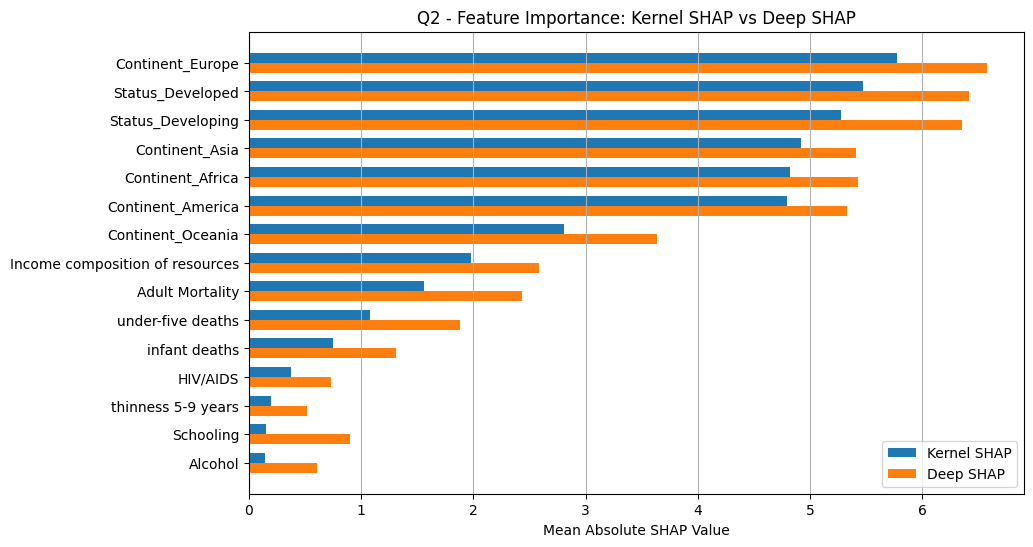

Saved: /content/q2_shap_outputs/q2_kernel_vs_deep_feature_importance.png


In [ ]:
top_n = 15
top_features = importance_df.head(top_n).copy()

plt.figure(figsize=(10, 6))

x = np.arange(len(top_features))
width = 0.35

plt.barh(
    x - width / 2,
    top_features["kernel_mean_abs_shap"],
    height=width,
    label="Kernel SHAP"
)

plt.barh(
    x + width / 2,
    top_features["deep_mean_abs_shap"],
    height=width,
    label="Deep SHAP"
)

plt.yticks(x, top_features["feature"])
plt.xlabel("Mean Absolute SHAP Value")
plt.title("Q2 - Feature Importance: Kernel SHAP vs Deep SHAP")
plt.legend()
plt.gca().invert_yaxis()
plt.grid(axis="x")

importance_fig_path = os.path.join(OUTPUT_DIR, "q2_kernel_vs_deep_feature_importance.png")
plt.savefig(importance_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", importance_fig_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>مقایسه اهمیت ویژگی‌ها در Kernel SHAP و Deep SHAP</h3>

<p>
مقایسه میانگین قدرمطلق مقادیر SHAP نشان می‌دهد که دو روش Kernel SHAP و Deep SHAP در رتبه‌بندی کلی ویژگی‌ها بسیار مشابه عمل کرده‌اند. در هر دو روش، ویژگی‌هایی مانند Continent_Europe، Status_Developed، Status_Developing و سایر ویژگی‌های مربوط به قاره در صدر جدول اهمیت قرار دارند.
</p>

<p>
تفاوت اصلی این است که مقدار عددی اهمیت در Deep SHAP کمی بزرگ‌تر دیده می‌شود، اما ترتیب کلی ویژگی‌های مهم تقریباً ثابت مانده است. این همخوانی نشان می‌دهد که توضیحات به دست آمده پایدار هستند و فقط به یک روش خاص وابسته نیستند.
</p>

</div>

In [ ]:
meta = explain_meta.reset_index(drop=True).copy()

selected_continent = None
selected_local_indices = None

for cont, group in meta.groupby("Continent"):
    unique_countries = group[country_col].unique()

    if len(unique_countries) >= 2:
        selected_continent = cont

        selected_indices = []

        for c in unique_countries[:2]:
            idx = group[group[country_col] == c].index[0]
            selected_indices.append(idx)

        selected_local_indices = selected_indices
        break

if selected_local_indices is None:
    print("Could not find two different countries in the same continent.")
    print("Falling back to two samples from the same continent.")

    for cont, group in meta.groupby("Continent"):
        if len(group) >= 2:
            selected_continent = cont
            selected_local_indices = group.index[:2].tolist()
            break

if selected_local_indices is None:
    raise ValueError("Could not select two local samples.")

print("Selected continent:", selected_continent)
print("Selected local indices:", selected_local_indices)

local_meta = meta.iloc[selected_local_indices].copy()

local_meta_path = os.path.join(OUTPUT_DIR, "q2_local_force_samples.csv")
local_meta.to_csv(local_meta_path, index=False)

display(local_meta)
print("Saved:", local_meta_path)

X_force_df = X_explain_df.iloc[selected_local_indices].copy()
kernel_force_values = kernel_shap_values[selected_local_indices]
deep_force_values = deep_shap_values[selected_local_indices]

Selected continent: Africa
Selected local indices: [np.int64(0), np.int64(5)]


,Country,Continent,Life expectancy,prediction,absolute_error
0,Namibia,Africa,65.9,60.301243,5.598757
5,Seychelles,Africa,72.1,69.092308,3.007692


Saved: /content/q2_shap_outputs/q2_local_force_samples.csv


<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>انتخاب نمونه‌ها برای تحلیل محلی</h3>

<p>
برای تحلیل محلی، دو کشور متفاوت از یک قاره انتخاب شدند تا رفتار مدل در سطح نمونه بررسی شود. در این اجرا، دو کشور Namibia و Seychelles از قاره آفریقا انتخاب شده‌اند. هدف این بخش این است که مشخص شود برای هر کشور خاص، کدام ویژگی‌ها باعث افزایش یا کاهش پیش‌بینی امید به زندگی شده‌اند.
</p>

<p>
تحلیل محلی با تحلیل کلی تفاوت دارد. در تحلیل کلی، میانگین اثر ویژگی‌ها روی تعداد زیادی نمونه بررسی می‌شود؛ اما در تحلیل محلی، فقط یک نمونه خاص توضیح داده می‌شود. بنابراین ممکن است ویژگی‌هایی که در سطح کلی مهم هستند، در یک نمونه خاص اثر متفاوتی داشته باشند.
</p>

</div>

<Figure size 640x480 with 0 Axes>

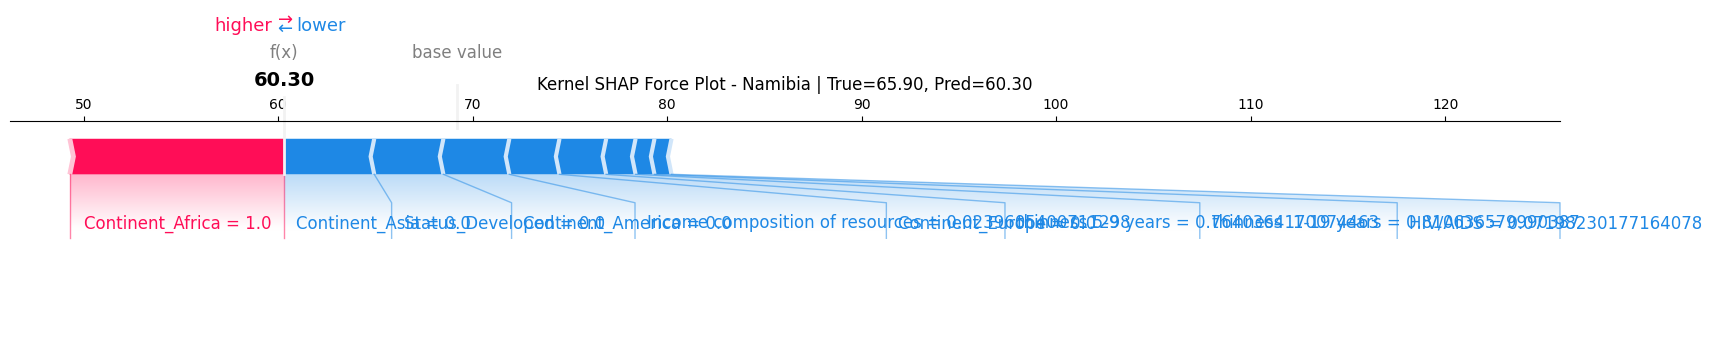

Saved: /content/q2_shap_outputs/q2_kernel_force_plot_sample_1.png


<Figure size 640x480 with 0 Axes>

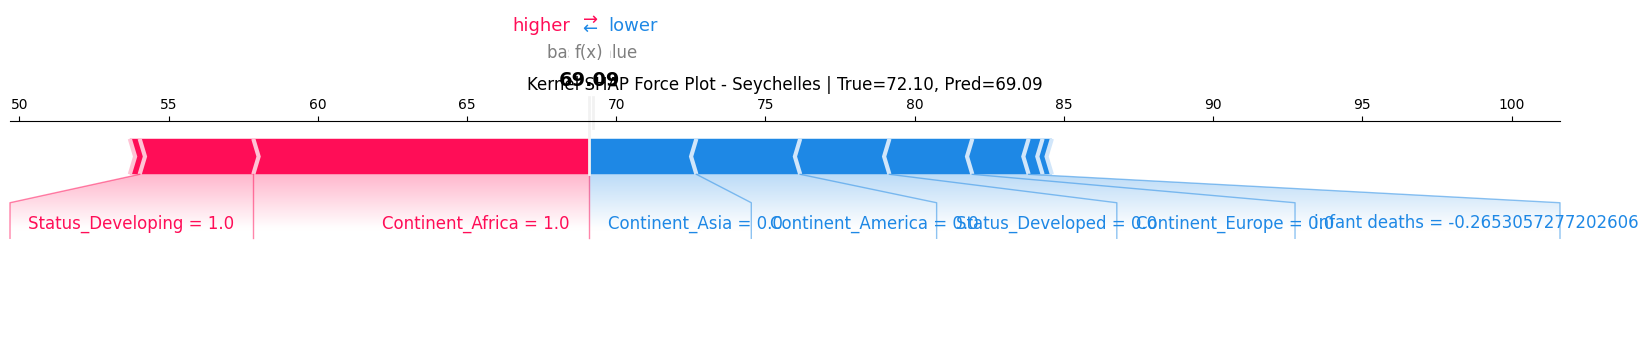

Saved: /content/q2_shap_outputs/q2_kernel_force_plot_sample_2.png


In [ ]:
kernel_expected_value = kernel_explainer.expected_value

if isinstance(kernel_expected_value, (list, np.ndarray)):
    kernel_expected_value = np.asarray(kernel_expected_value).ravel()[0]

for i, local_idx in enumerate(selected_local_indices):
    country_name = local_meta.iloc[i][country_col]
    true_value = local_meta.iloc[i][target_col]
    pred_value = local_meta.iloc[i]["prediction"]

    plt.figure()

    shap.force_plot(
        kernel_expected_value,
        kernel_force_values[i],
        X_force_df.iloc[i],
        matplotlib=True,
        show=False
    )

    plt.title(
        f"Kernel SHAP Force Plot - {country_name} | "
        f"True={true_value:.2f}, Pred={pred_value:.2f}"
    )

    force_path = os.path.join(
        OUTPUT_DIR,
        f"q2_kernel_force_plot_sample_{i+1}.png"
    )

    plt.savefig(force_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", force_path)

<Figure size 640x480 with 0 Axes>

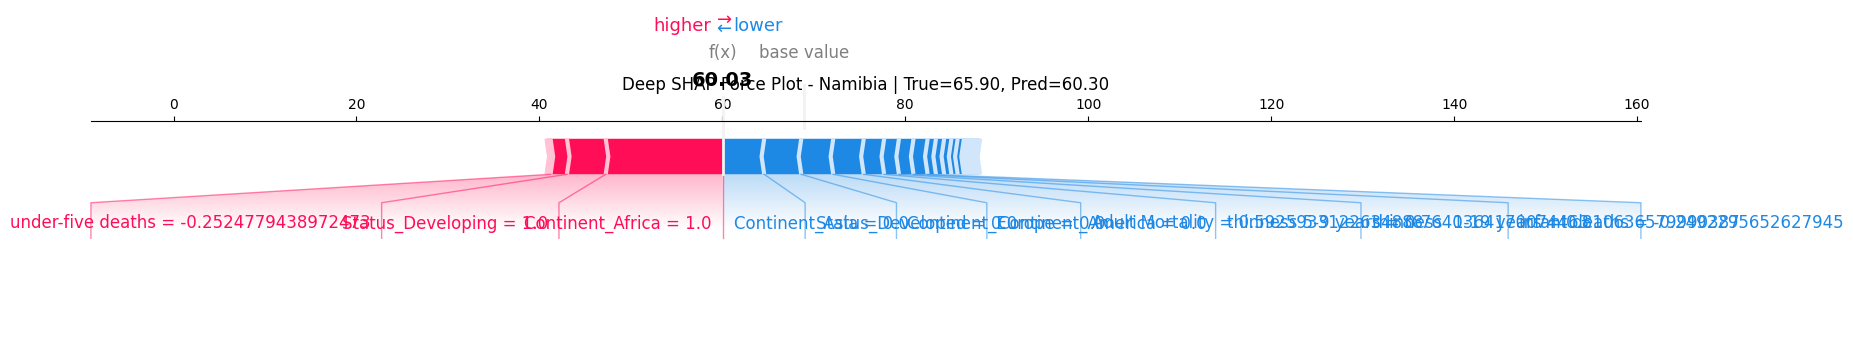

Saved: /content/q2_shap_outputs/q2_deep_force_plot_sample_1.png


<Figure size 640x480 with 0 Axes>

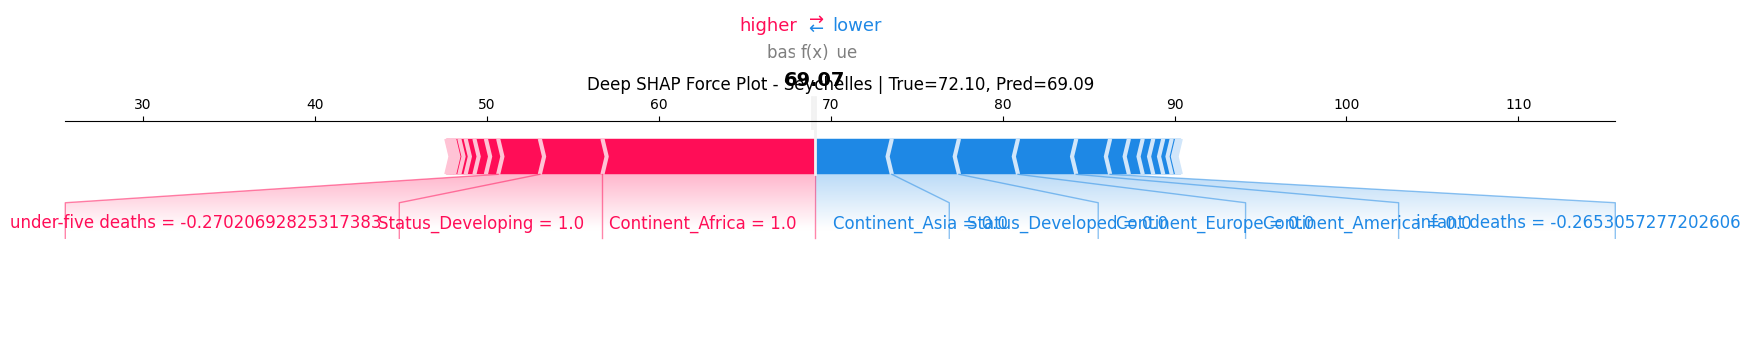

Saved: /content/q2_shap_outputs/q2_deep_force_plot_sample_2.png


In [ ]:
deep_expected_value = deep_explainer.expected_value

if isinstance(deep_expected_value, list):
    deep_expected_value = deep_expected_value[0]

deep_expected_value = np.asarray(deep_expected_value).ravel()[0]

for i, local_idx in enumerate(selected_local_indices):
    country_name = local_meta.iloc[i][country_col]
    true_value = local_meta.iloc[i][target_col]
    pred_value = local_meta.iloc[i]["prediction"]

    plt.figure()

    shap.force_plot(
        deep_expected_value,
        deep_force_values[i],
        X_force_df.iloc[i],
        matplotlib=True,
        show=False
    )

    plt.title(
        f"Deep SHAP Force Plot - {country_name} | "
        f"True={true_value:.2f}, Pred={pred_value:.2f}"
    )

    force_path = os.path.join(
        OUTPUT_DIR,
        f"q2_deep_force_plot_sample_{i+1}.png"
    )

    plt.savefig(force_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", force_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>نکته درباره Force Plotها</h3>

<p>
Force Plotها نشان می‌دهند که هر ویژگی چگونه مقدار پایه مدل را به سمت مقدار پیش‌بینی‌شده نهایی حرکت می‌دهد. ویژگی‌هایی که اثر مثبت دارند، پیش‌بینی امید به زندگی را افزایش می‌دهند و ویژگی‌هایی که اثر منفی دارند، مقدار پیش‌بینی را کاهش می‌دهند.
</p>

<p>
با این حال، به دلیل تعداد زیاد ویژگی‌ها و وجود چندین ویژگی one-hot، نمودارهای Force Plot در گزارش ثابت ممکن است خوانایی کافی نداشته باشند. به همین دلیل، برای تحلیل نهایی بهتر است از Waterfall Plot استفاده شود، زیرا همان اطلاعات را به صورت مرتب‌تر و قابل خواندن‌تر نمایش می‌دهد.
</p>

</div>

In [ ]:
model_path = os.path.join(OUTPUT_DIR, "q2_life_expectancy_mlp_model.pth")

torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "feature_names": feature_names,
    "target_col": target_col,
    "country_col": country_col,
    "eval": eval_df.to_dict(orient="records")
}, model_path)

print("Saved model:", model_path)

print("\nImportant output files:")
print("Evaluation:", eval_path)
print("Predictions:", pred_path)
print("True vs Predicted:", pred_plot_path)
print("Kernel SHAP summary:", kernel_summary_path)
print("Deep SHAP summary:", deep_summary_path)
print("Feature importance table:", importance_path)
print("Feature importance plot:", importance_fig_path)
print("Local force samples:", local_meta_path)

print("\nAll files in OUTPUT_DIR:")
!ls -lah {OUTPUT_DIR}

Saved model: /content/q2_shap_outputs/q2_life_expectancy_mlp_model.pth

Important output files:
Evaluation: /content/q2_shap_outputs/q2_model_evaluation.csv
Predictions: /content/q2_shap_outputs/q2_test_predictions.csv
True vs Predicted: /content/q2_shap_outputs/q2_true_vs_predicted.png
Kernel SHAP summary: /content/q2_shap_outputs/q2_kernel_shap_summary.png
Deep SHAP summary: /content/q2_shap_outputs/q2_deep_shap_summary.png
Feature importance table: /content/q2_shap_outputs/q2_shap_feature_importance.csv
Feature importance plot: /content/q2_shap_outputs/q2_kernel_vs_deep_feature_importance.png
Local force samples: /content/q2_shap_outputs/q2_local_force_samples.csv

All files in OUTPUT_DIR:
total 2.0M
drwxr-xr-x 2 root root 4.0K Jul  8 04:41 .
drwxr-xr-x 1 root root 4.0K Jul  8 04:36 ..
-rw-r--r-- 1 root root 258K Jul  8 05:06 q2_deep_force_plot_sample_1.png
-rw-r--r-- 1 root root 217K Jul  8 05:06 q2_deep_force_plot_sample_2.png
-rw-r--r-- 1 root root 280K Jul  8 04:40 q2_deep_shap_

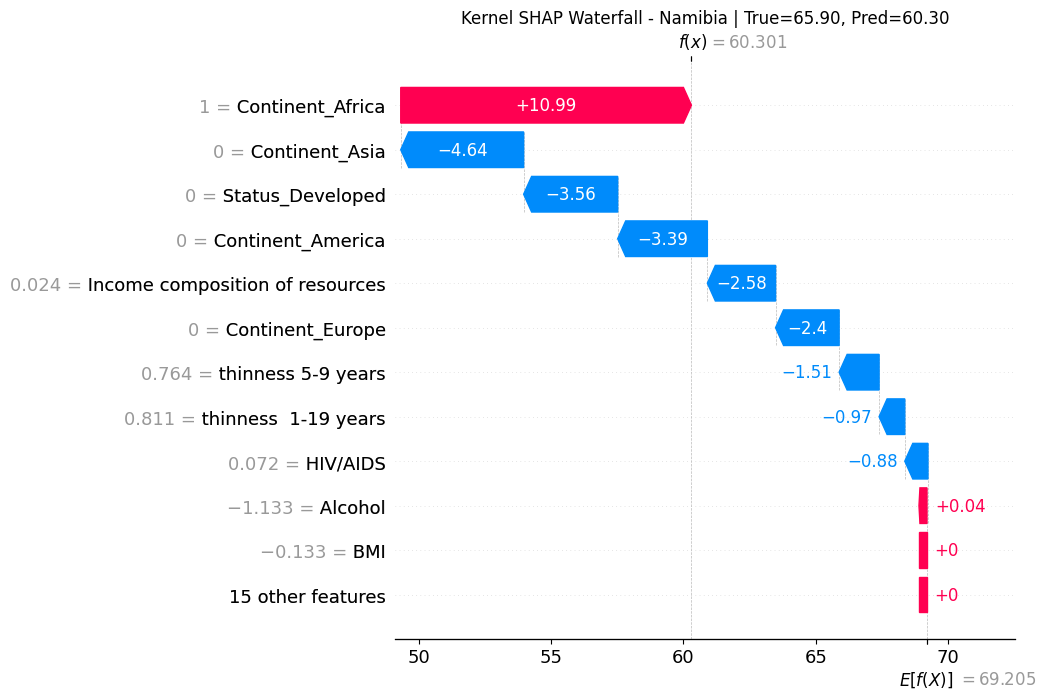

Saved: /content/q2_shap_outputs/q2_kernel_waterfall_Namibia.png


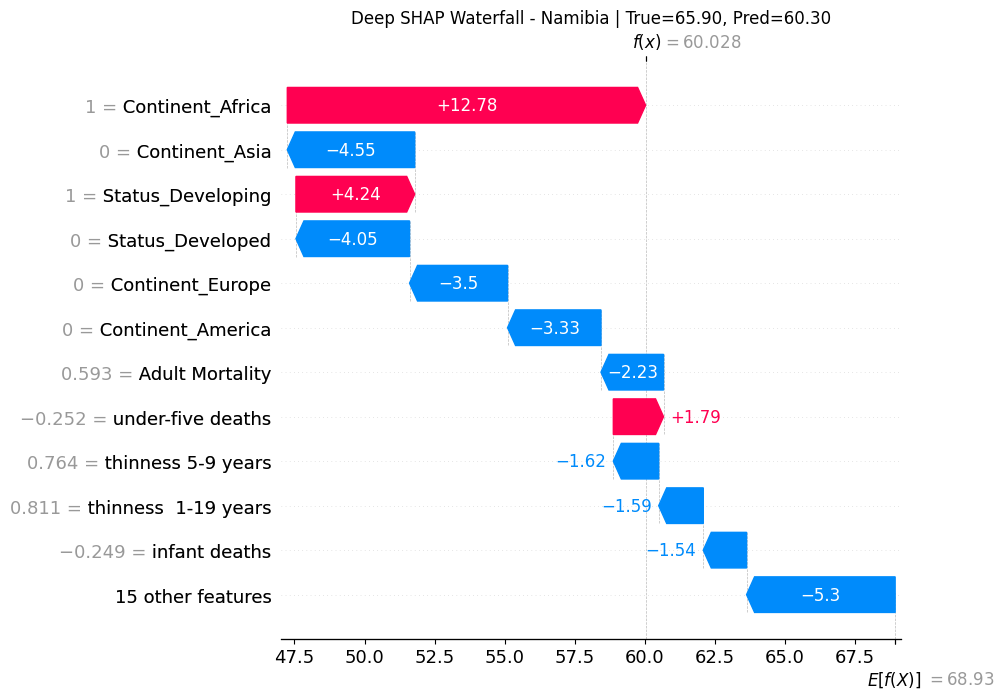

Saved: /content/q2_shap_outputs/q2_deep_waterfall_Namibia.png


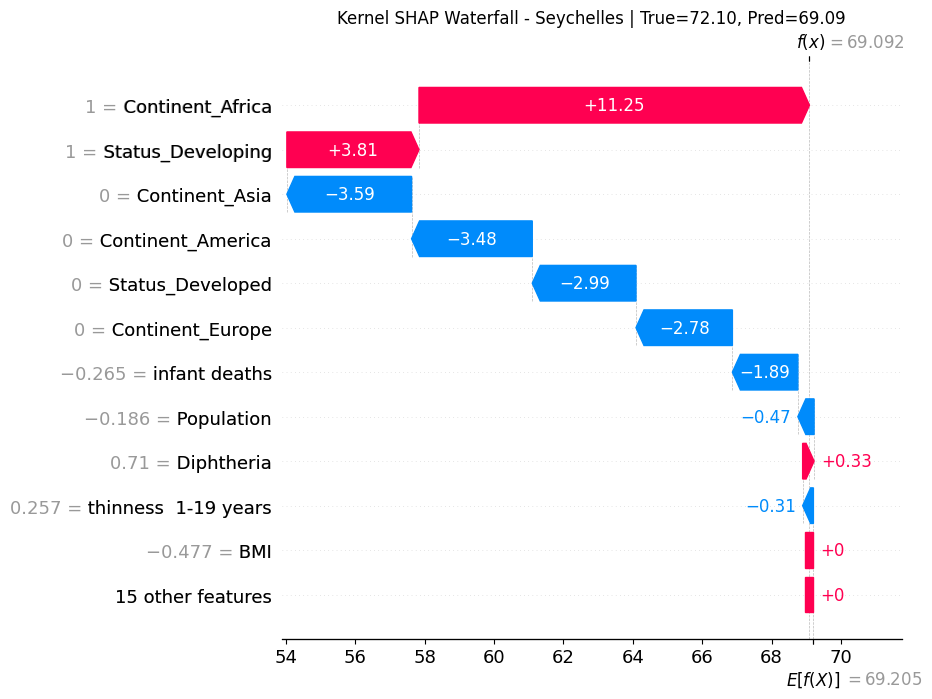

Saved: /content/q2_shap_outputs/q2_kernel_waterfall_Seychelles.png


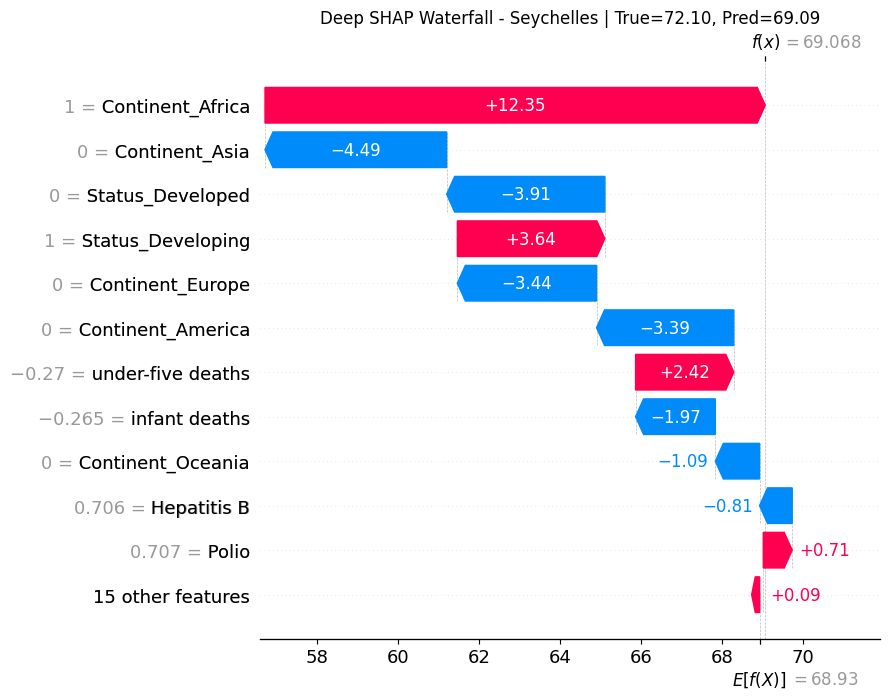

Saved: /content/q2_shap_outputs/q2_deep_waterfall_Seychelles.png


In [ ]:
def get_scalar_expected_value(expected_value):
    if isinstance(expected_value, list):
        expected_value = expected_value[0]
    if isinstance(expected_value, np.ndarray):
        expected_value = expected_value.ravel()[0]
    return float(expected_value)


kernel_base_value = get_scalar_expected_value(kernel_explainer.expected_value)
deep_base_value = get_scalar_expected_value(deep_explainer.expected_value)

waterfall_paths = []

for i in range(len(selected_local_indices)):
    country_name = local_meta.iloc[i][country_col]
    true_value = local_meta.iloc[i][target_col]
    pred_value = local_meta.iloc[i]["prediction"]


    kernel_exp = shap.Explanation(
        values=kernel_force_values[i],
        base_values=kernel_base_value,
        data=X_force_df.iloc[i].values,
        feature_names=feature_names
    )

    plt.figure(figsize=(9, 6))
    shap.plots.waterfall(
        kernel_exp,
        max_display=12,
        show=False
    )

    plt.title(
        f"Kernel SHAP Waterfall - {country_name} | "
        f"True={true_value:.2f}, Pred={pred_value:.2f}"
    )

    kernel_waterfall_path = os.path.join(
        OUTPUT_DIR,
        f"q2_kernel_waterfall_{country_name}.png"
    )

    plt.savefig(kernel_waterfall_path, dpi=300, bbox_inches="tight")
    plt.show()

    waterfall_paths.append(kernel_waterfall_path)
    print("Saved:", kernel_waterfall_path)


    deep_exp = shap.Explanation(
        values=deep_force_values[i],
        base_values=deep_base_value,
        data=X_force_df.iloc[i].values,
        feature_names=feature_names
    )

    plt.figure(figsize=(9, 6))
    shap.plots.waterfall(
        deep_exp,
        max_display=12,
        show=False
    )

    plt.title(
        f"Deep SHAP Waterfall - {country_name} | "
        f"True={true_value:.2f}, Pred={pred_value:.2f}"
    )

    deep_waterfall_path = os.path.join(
        OUTPUT_DIR,
        f"q2_deep_waterfall_{country_name}.png"
    )

    plt.savefig(deep_waterfall_path, dpi=300, bbox_inches="tight")
    plt.show()

    waterfall_paths.append(deep_waterfall_path)
    print("Saved:", deep_waterfall_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل Waterfall Plotهای محلی</h3>

<p>
در نمونه Namibia، مقدار واقعی امید به زندگی 65.90 و مقدار پیش‌بینی‌شده مدل حدود 60.30 بوده است؛ بنابراین مدل امید به زندگی را کمتر از مقدار واقعی تخمین زده است. در این نمونه، ویژگی Continent_Africa اثر افزایشی داشته، اما نبود ویژگی‌هایی مانند Continent_Europe، Status_Developed، Continent_Asia و Continent_America باعث کاهش مقدار پیش‌بینی شده است.
</p>

<p>
در نمونه Seychelles، مقدار واقعی امید به زندگی 72.10 و مقدار پیش‌بینی‌شده مدل حدود 69.09 بوده است. خطای مدل برای این کشور کمتر از Namibia است. در این نمونه نیز Continent_Africa و Status_Developing اثر افزایشی دارند، اما نبود ویژگی‌هایی مانند Status_Developed، Continent_Europe و Continent_Asia اثر کاهشی ایجاد کرده است.
</p>

<p>
این نتایج نشان می‌دهند که مدل برای هر نمونه خاص، ترکیبی از عوامل منطقه‌ای، توسعه‌ای و سلامت عمومی را در تصمیم‌گیری خود استفاده می‌کند. بنابراین SHAP کمک می‌کند بفهمیم مدل فقط چه مقدار پیش‌بینی کرده، بلکه چرا به آن پیش‌بینی رسیده است.
</p>

</div>

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل جدول ویژگی‌های مؤثر محلی</h3>

<p>
جدول ویژگی‌های محلی نشان می‌دهد که برای هر نمونه، کدام ویژگی‌ها بیشترین سهم مثبت یا منفی را در خروجی مدل داشته‌اند. این جدول مکمل Waterfall Plot است و باعث می‌شود بتوان سهم ویژگی‌ها را به صورت عددی و مرتب‌شده مشاهده کرد.
</p>

<p>
در تحلیل محلی باید دقت کرد که اهمیت یک ویژگی برای یک کشور خاص لزوماً به معنی اهمیت آن در کل داده‌ها نیست. ممکن است یک ویژگی در سطح جهانی اهمیت متوسطی داشته باشد، اما برای یک نمونه خاص نقش بسیار پررنگی پیدا کند. به همین دلیل، ترکیب تحلیل کلی و تحلیل محلی برای توضیح‌پذیری مدل ضروری است.
</p>

</div>

In [ ]:
local_contribution_rows = []

for i in range(len(selected_local_indices)):
    country_name = local_meta.iloc[i][country_col]
    continent_name = local_meta.iloc[i]["Continent"]
    true_value = local_meta.iloc[i][target_col]
    pred_value = local_meta.iloc[i]["prediction"]

    for method_name, shap_values in [
        ("Kernel SHAP", kernel_force_values[i]),
        ("Deep SHAP", deep_force_values[i])
    ]:
        temp_df = pd.DataFrame({
            "country": country_name,
            "continent": continent_name,
            "method": method_name,
            "true_life_expectancy": true_value,
            "predicted_life_expectancy": pred_value,
            "feature": feature_names,
            "feature_value_after_preprocessing": X_force_df.iloc[i].values,
            "shap_value": shap_values
        })

        temp_df["abs_shap_value"] = temp_df["shap_value"].abs()

        temp_df["effect_direction"] = np.where(
            temp_df["shap_value"] > 0,
            "increases prediction",
            "decreases prediction"
        )

        temp_df = temp_df.sort_values(
            "abs_shap_value",
            ascending=False
        ).head(10)

        local_contribution_rows.append(temp_df)

local_contributions_df = pd.concat(
    local_contribution_rows,
    axis=0
).reset_index(drop=True)

local_contrib_path = os.path.join(
    OUTPUT_DIR,
    "q2_local_top_contributions.csv"
)

local_contributions_df.to_csv(local_contrib_path, index=False)

display(local_contributions_df)

print("Saved:", local_contrib_path)

,country,continent,method,true_life_expectancy,predicted_life_expectancy,feature,feature_value_after_preprocessing,shap_value,abs_shap_value,effect_direction
0,Namibia,Africa,Kernel SHAP,65.9,60.301243,Continent_Africa,1.000000,10.986922,10.986922,increases prediction
1,Namibia,Africa,Kernel SHAP,65.9,60.301243,Continent_Asia,0.000000,-4.644835,4.644835,decreases prediction
2,Namibia,Africa,Kernel SHAP,65.9,60.301243,Status_Developed,0.000000,-3.555065,3.555065,decreases prediction
3,Namibia,Africa,Kernel SHAP,65.9,60.301243,Continent_America,0.000000,-3.389617,3.389617,decreases prediction
4,Namibia,Africa,Kernel SHAP,65.9,60.301243,Income composition of resources,0.023961,-2.578265,2.578265,decreases prediction
5,Namibia,Africa,Kernel SHAP,65.9,60.301243,Continent_Europe,0.000000,-2.402386,2.402386,decreases prediction
6,Namibia,Africa,Kernel SHAP,65.9,60.301243,thinness 5-9 years,0.764036,-1.510424,1.510424,decreases prediction
7,Namibia,Africa,Kernel SHAP,65.9,60.301243,thinness 1-19 years,0.810637,-0.971177,0.971177,decreases prediction
8,Namibia,Africa,Kernel SHAP,65.9,60.301243,HIV/AIDS,0.071982,-0.875846,0.875846,decreases prediction
9,Namibia,Africa,Kernel SHAP,65.9,60.301243,Alcohol,-1.133020,0.036621,0.036621,increases prediction


Saved: /content/q2_shap_outputs/q2_local_top_contributions.csv


<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>جمع‌بندی نهایی پرسش ۲</h3>

<p>
در این پرسش، یک مدل MLP برای پیش‌بینی امید به زندگی آموزش داده شد و سپس با استفاده از Kernel SHAP و Deep SHAP توضیح داده شد. مدل از نظر پیش‌بینی عملکرد قابل قبولی داشت و مقدار R² حدود 0.81 نشان داد که مدل توانسته بخش قابل توجهی از تغییرات امید به زندگی را یاد بگیرد.
</p>

<p>
تحلیل‌های SHAP نشان دادند که ویژگی‌های مربوط به قاره، وضعیت توسعه‌یافتگی، ترکیب درآمدی منابع، مرگ‌ومیر بزرگسالان و مرگ‌ومیر کودکان از مهم‌ترین عوامل مورد استفاده مدل هستند. شباهت نتایج Kernel SHAP و Deep SHAP نشان می‌دهد که توضیحات به دست آمده نسبتاً پایدار هستند.
</p>

<p>
در تحلیل محلی برای Namibia و Seychelles مشاهده شد که برخی ویژگی‌ها خروجی مدل را افزایش و برخی دیگر آن را کاهش می‌دهند. Waterfall Plotها نشان دادند که مدل برای هر کشور چگونه از ترکیب ویژگی‌های منطقه‌ای، توسعه‌ای و سلامت عمومی استفاده کرده است. در مجموع، SHAP باعث شد مدل از یک ابزار صرفاً پیش‌بینی‌کننده به یک مدل قابل تحلیل و قابل توضیح تبدیل شود.
</p>

<p>
با این حال، باید توجه داشت که SHAP رابطه علّی را اثبات نمی‌کند. همچنین ویژگی‌هایی مانند Continent و Status ممکن است نقش proxy برای شرایط اقتصادی و اجتماعی کشورها داشته باشند. بنابراین برای تحلیل سیاست‌گذاری یا نتیجه‌گیری علّی، باید آزمایش‌های تکمیلی مانند آموزش مدل بدون ویژگی Continent یا ارزیابی جداگانه برای هر قاره انجام شود.
</p>

</div>

# Conclusion

This experiment demonstrates how explainability methods can improve the understanding of machine learning models.

Key observations:

- SHAP provides insights into feature importance and prediction behavior.
- Global explanations help identify important patterns learned by the model.
- Local explanations provide transparency for individual predictions.

Explainability is an important component of trustworthy machine learning systems.